## Imports 

In [41]:
import pandas as pd
import re
import csv

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from pathlib import Path
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from gensim.models import Phrases


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 1500000 


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ftzavellos/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ftzavellos/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ftzavellos/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 20.8 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [45]:
FOE_ECHR_PATH = Path("..") / "dataset" / "foe_echr.csv"
NE_PATH = Path("..") / "dataset" / "named_entities_foe.csv"
PREPROCESSED_DF_PATH = Path("..") / "dataset" / "preprocessed_dataset.csv"
PROCESSED_FACTS_PATH = Path("..") / "dataset" / "processed_facts.csv"

## Functions

Load and clean up the NaN values of the dataset

In [4]:
df_dataset = pd.read_csv(FOE_ECHR_PATH, index_col=0, encoding = 'utf-8')
print('Number of nan values in the facts column of the foe dataset is' , df_dataset[['facts']].isna().sum())
df_dataset = df_dataset.dropna(subset=['facts'])
df_dataset = df_dataset.reset_index(drop=True)

Number of nan values in the facts column of the foe dataset is facts    40
dtype: int64


Cleaning up the text

In [ ]:
def clean_text(text: str) -> str:
    """
    Cleans a text string by removing markdown elements, special characters, 
    and unnecessary whitespace.

    Args:
        text (str): The input text to be cleaned.

    Returns:
        str: The cleaned text with markdown symbols, special characters, 
             and excess spaces removed.
             
    """
    # Remove markdown elements and special characters
    text = re.sub(r'#', '', text)  # Remove '#'
    text = re.sub(r'[-]', '', text)  # Remove '-'
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with a single space
    text = re.sub(r'\\[a-zA-Z0-9]+', '', text)  # Remove any escaped sequences like \xa0
    return text

Clean up the facts and full text column

In [6]:
df_dataset['facts'] = df_dataset['facts'].apply(clean_text)
df_dataset['full_text'] = df_dataset['full_text'].apply(clean_text)

Recognise named entities from the text

In [7]:
def extract_named_entities(text_list: list) -> list:
    """
    Extracts unique named entities from a list of text strings.

    Args:
        text_list (list): List of text strings to process for named entities.

    Returns:
        list: List of unique named entities.
    """
    entities = [ent.text for doc in map(nlp, text_list) for ent in doc.ents]
    return list(dict.fromkeys(entities))  # Remove duplicates while preserving order

Remove named entities

In [10]:
def remove_named_entities(text: str, entities_list: list) -> str:
    """
    Removes all occurrences of entities in the provided list from the given text.

    Args:
        text (str): The input text to remove entities from.
        entities_list (list): List of entities to remove.

    Returns:
        str: Text with entities removed.
    """
    for entity in entities_list:
        entity_regex = re.compile(r'\b' + re.escape(entity) + r'\b', re.IGNORECASE)
        text = entity_regex.sub('', text)
    return text.strip()

Tie the two functions together to extract entities if the extraction has not been performed before and remove them from the case facts text

In [8]:
def extract_and_remove_entities(df: pd.DataFrame, text_column: str, entities_file_path: Path) -> pd.DataFrame:
    """
    Extracts named entities from a DataFrame column and removes them from the text.
    If a CSV file with named entities exists, it loads them; otherwise, it extracts 
    entities and saves them to the CSV.

    Args:
        df (pd.DataFrame): DataFrame containing the text data.
        text_column (str): Column name containing the text for entity extraction.
        entities_file_path (Path): Path to the CSV file to save or load named entities.

    Returns:
        pd.DataFrame: DataFrame with a new column where named entities have been removed.
    """
    # Check if entities file exists and load or extract entities
    if entities_file_path.exists():
        entities_df = pd.read_csv(entities_file_path, header=None, names=['entity'], encoding='utf-8')
        entities_list = [str(entity) for entity in entities_df['entity'] if entity and str(entity).lower() != 'nan']
    else:
        # Extract named entities and save to CSV
        text_list = df[text_column].dropna().astype(str).tolist()
        entities_list = extract_named_entities(text_list)
        with open(entities_file_path, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)
            for entity in entities_list:
                writer.writerow([entity])

    # Remove entities from text column and create a new column with entities removed
    df[f"{text_column}_ne_removed"] = df[text_column].apply(lambda x: remove_named_entities(str(x), entities_list) if pd.notna(x) else x)
    
    return df

In [11]:
df_dataset = extract_and_remove_entities(df_dataset, 'facts', NE_PATH)

Remove stopwords (the English stopwords and the custom stopwords list)

In [29]:
def remove_stopwords(text: str, custom_stopwords: list = None) -> str:
    """
    Removes stop words from the input text, combining the NLTK English stop words 
    with any provided custom stop words.

    Args:
        text (str): The input text from which stop words should be removed.
        custom_stopwords (list): An optional set of custom stop words to add to NLTK's English stop words.

    Returns:
        str: Text with stop words removed.
    """
    stop_words = stopwords.words('english')

    if custom_stopwords:
        stop_words.extend(custom_stopwords)

    for entity in stop_words:
            # Use word boundaries to ensure whole phrases are matched
            stopword_regex = re.compile(r'\b' + re.escape(entity) + r'\b', re.IGNORECASE)
            text = stopword_regex.sub('', text)
    return text.strip()


In [30]:
custom_stopwords = [
'also',
'may', 
'could', 
'would', 
'must', 
'applicant', 
'applicants'
'court',
'article',
'case',
'convetion',
'see',
'right',
'government',
'paragraph',
'law',
'state',
'detention',
'authority',
'application',
'one']

In [31]:
df_dataset['cleaned_facts'] = df_dataset['facts_ne_removed'].apply(lambda x: remove_stopwords(x, custom_stopwords))

Save the entire dataset in csv format

In [33]:
df_dataset.to_csv(PREPROCESSED_DF_PATH)

Work on the facts column

In [ ]:
clean_facts = df_dataset['cleaned_facts']
clean_facts

Clean up the column

In [35]:
def further_preprocessing(text):
    """
    Performs further preprocessing on the input text, including cleaning, lemmatization,
    and removal of unnecessary characters.

    Steps:
        1. Converts the text to lowercase.
        2. Removes characters that are not letters or spaces.
        3. Lemmatizes words in the text using a language model.
        4. Removes single-character tokens.
        5. Joins the tokens back into a single string.
        6. Cleans up duplicate or trailing whitespace.

    Args:
        text (str): The input text to preprocess.

    Returns:
        str: The fully preprocessed text.
        """
    # Convert the text to lowercase
    text = text.lower()

    # Remove anything that is not a word or space
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Lemmatize the text
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]
    
    # Remove single character strings
    tokens = [token for token in tokens if len(token) > 1]

    text = " ".join(tokens)

    # Remove duplicate whitespace
    text = re.sub(r'\s+', ' ', text)

    # Remove any extra leading or trailing whitespace left after processing
    text = text.strip()
    
    return text

In [ ]:
clean_facts = clean_facts.apply(further_preprocessing)
clean_facts

Create a wordcloud to observe the most commonly found words

In [38]:
def plot_wordcloud(texts: pd.Series, color: str = '#40E0D0', colormap: str = 'ocean') -> None:
    """
    Generates and displays a word cloud for the given text data.

    Args:
        texts (pd.Series): A series of text data.
        color (str): Background color of the word cloud.
        colormap (str): Colormap to use for word cloud.
    """
    combined_text = " ".join(texts)
    wordcloud = WordCloud(width=500, height=500, background_color=color, colormap=colormap).generate(combined_text)
    plt.figure(figsize=(10, 10))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()


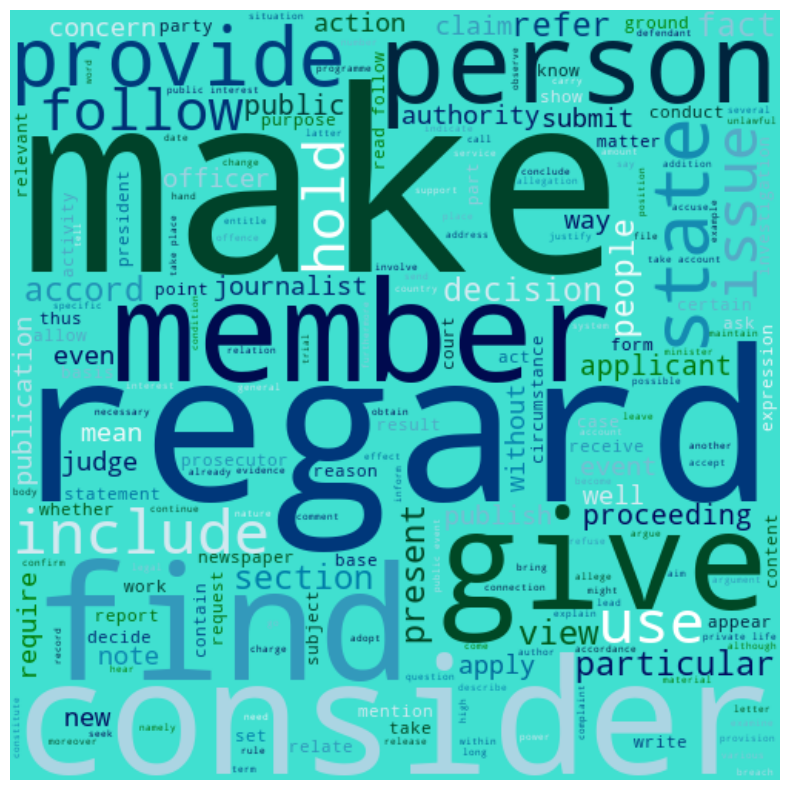

In [39]:
plot_wordcloud(clean_facts)

Create bigrams 

In [42]:
def generate_bigrams(texts: pd.Series, min_count: int = 5, threshold: int = 20) -> list:
    """
    Generates bigrams from the text data using Gensim's Phrases model.

    Args:
        texts (pd.Series): A series of text data split into tokens.
        min_count (int): Minimum count for bigram inclusion.
        threshold (int): Threshold for scoring word pair association.

    Returns:
        list: List of tokenized texts with bigrams.
    """
    sentence_stream = [doc.split(" ") for doc in texts]
    bigram_model = Phrases(sentence_stream, min_count=min_count, threshold=threshold)
    return [bigram_model[doc] for doc in sentence_stream]


In [ ]:
clean_facts_bigrams = generate_bigrams(clean_facts,7)
clean_facts_bigrams

Save the facts list in a csv

In [48]:
df_bigrams = pd.DataFrame({'facts': [' '.join(bigram) for bigram in clean_facts_bigrams]})
df_bigrams.to_csv(PROCESSED_FACTS_PATH)